**Data Overview**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("churn_data.csv")

In [5]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [7]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


**Data Cleaning**

In [8]:
# Dropping unnecessary columns
df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1, inplace=True)

In [9]:
# Checking for missing values
df.isnull().sum()

,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0
HasCrCard,0
IsActiveMember,0
EstimatedSalary,0


In [11]:
# Converting target variable to the desired datatype
df['Exited'] = df['Exited'].astype(int)

In [12]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


**EDA (Exploratory Data Analysis)**

The goal of EDA is to understand the dataset, identify patterns, detect anomalies, and extract meaningful insights.

In this section, we:
- Analyze the distribution of the target variable (Churn)
- Explore relationships between features and churn
- Identify trends in numerical and categorical variables
- Visualize correlations between features

EDA helps in forming hypotheses and guiding feature selection for modeling.

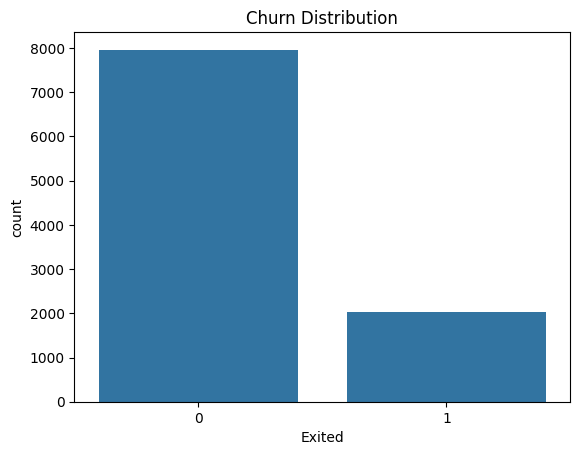

In [15]:

sns.countplot(x='Exited', data=df)
plt.title("Churn Distribution")
plt.show()

Churn Distribution

This plot shows the proportion of customers who have churned vs retained.

Insight:
- Helps identify class imbalance
- Important for choosing evaluation metrics and handling imbalance

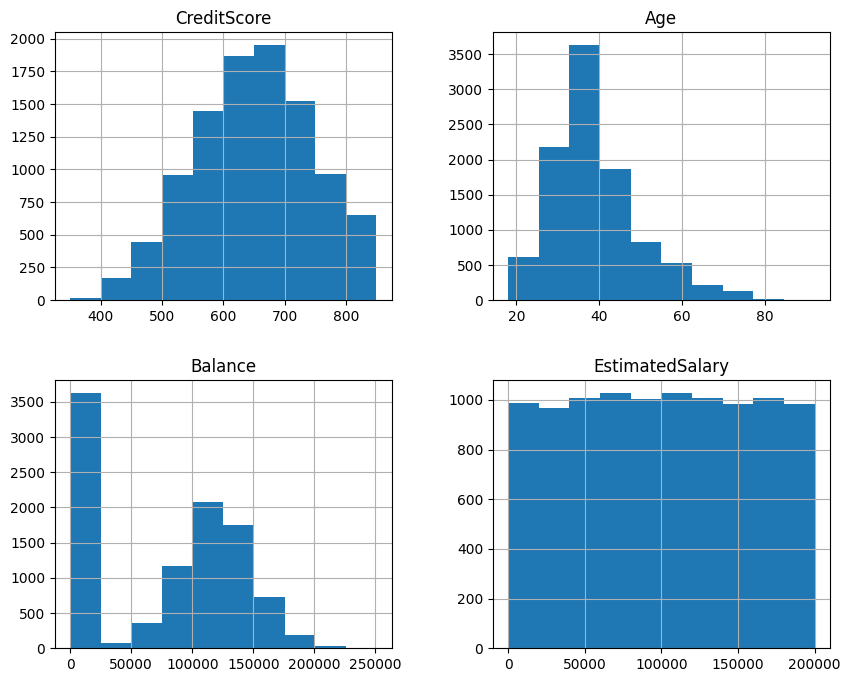

In [16]:
num_cols = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary']

df[num_cols].hist(figsize=(10,8))
plt.show()

Distribution of Numerical Features

These histograms show how numerical variables are distributed.

Insight:
- Detect skewness and outliers
- Understand data spread and central tendency

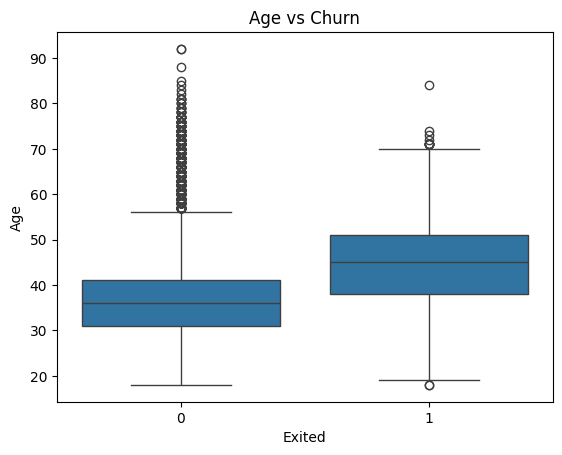

In [17]:
sns.boxplot(x='Exited', y='Age', data=df)
plt.title("Age vs Churn")
plt.show()

Age vs Churn

This boxplot compares age distribution for churned and non-churned customers.

Insight:
- Helps identify whether age influences churn behavior
- Outliers and median differences are visible

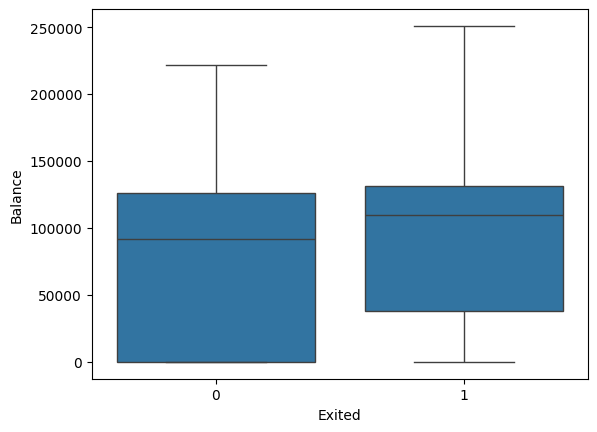

In [18]:
sns.boxplot(x='Exited', y='Balance', data=df)
plt.show()

Balance vs Churn

This visualization shows how account balance differs between churned and retained customers.

Insight:
- Higher balance customers may show different churn behavior
- Useful for business targeting strategies

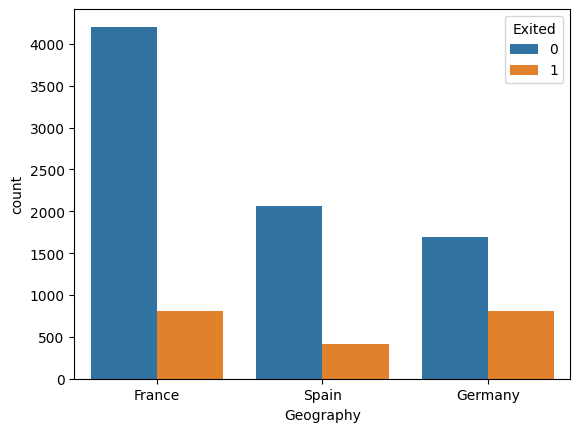

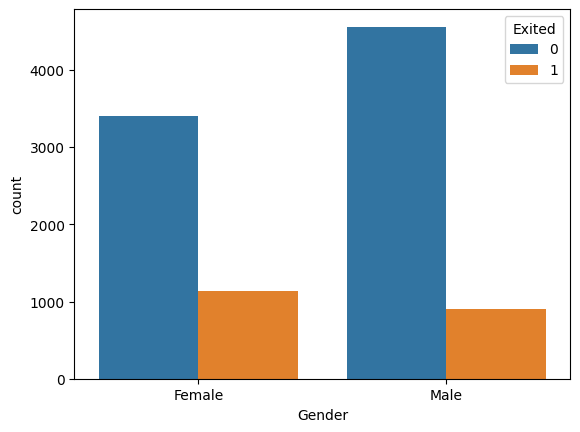

In [19]:
sns.countplot(x='Geography', hue='Exited', data=df)
plt.show()

sns.countplot(x='Gender', hue='Exited', data=df)
plt.show()

Categorical Feature Analysis

These plots show churn distribution across categories like Geography and Gender.

Insight:
- Helps identify segments with higher churn rates
- Useful for segmentation strategies

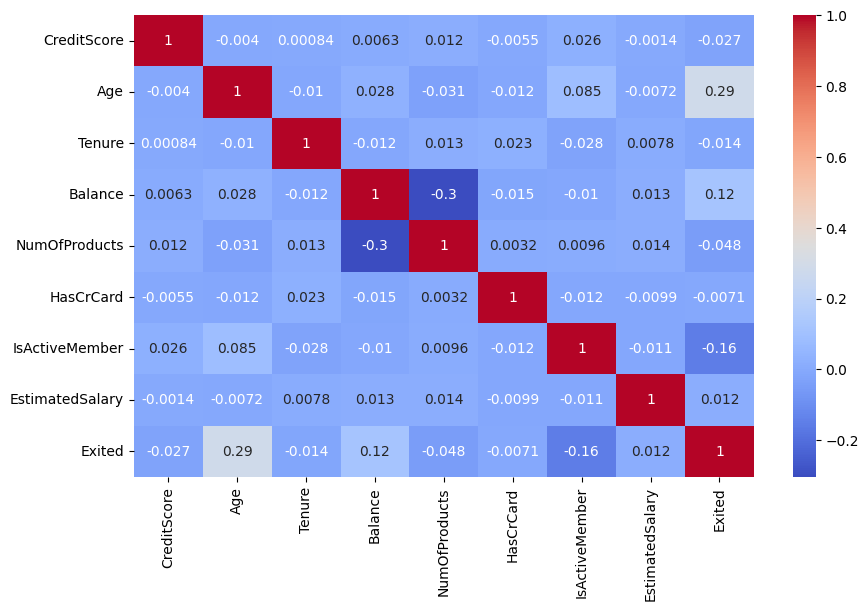

In [20]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

Correlation Heatmap

This heatmap shows relationships between numerical variables.

Insight:
- Helps identify strong positive/negative correlations
- Useful for feature selection

**Advanced Statistical Analysis**

This section validates relationships between variables using statistical tests.

We use:
- Chi-Square Test → for categorical variables
- T-Test → for numerical variables
- Correlation Analysis → for relationships
- VIF → to detect multicollinearity

These tests help ensure that our findings are statistically significant and not due to randomness.

In [21]:
from scipy.stats import chi2_contingency

# Geography vs Churn
contingency = pd.crosstab(df['Geography'], df['Exited'])

chi2, p, dof, expected = chi2_contingency(contingency)

print("Chi-square p-value:", p)

Chi-square p-value: 3.8303176053541544e-66


Chi-Square Test (Categorical vs Churn)

This test checks whether there is a significant relationship between categorical variables and churn.

Hypothesis:
- H0: No relationship exists
- H1: Significant relationship exists

Interpretation:
- If p-value < 0.05 → Reject H0 → Feature impacts churn

In [22]:
from scipy.stats import ttest_ind

churn = df[df['Exited'] == 1]['Balance']
no_churn = df[df['Exited'] == 0]['Balance']

t_stat, p_val = ttest_ind(churn, no_churn)

print("T-test p-value:", p_val)

T-test p-value: 1.2755633191525477e-32


T-Test (Numerical vs Churn)

This test compares the mean values of a numerical feature between churned and non-churned customers.

Hypothesis:
- H0: Means are equal
- H1: Means are different

Interpretation:
- If p-value < 0.05 → Significant difference exists

In [23]:
df.corr(numeric_only=True)['Exited'].sort_values(ascending=False)

,Exited
Exited,1.000000
Age,0.285323
Balance,0.118533
EstimatedSalary,0.012097
HasCrCard,-0.007138
Tenure,-0.014001
CreditScore,-0.027094
NumOfProducts,-0.047820
IsActiveMember,-0.156128


Correlation Analysis

This shows how strongly numerical variables are related to churn.

Insight:
- Positive correlation → increases churn probability
- Negative correlation → reduces churn probability

**Machine Learning**

In this section, we build predictive models to classify whether a customer will churn.

Steps:
- Data preprocessing
- Model training
- Model evaluation
- Feature importance analysis

We use multiple models to compare performance and improve accuracy.

Data Preprocessing

We prepare the dataset for machine learning by:
- Encoding categorical variables
- Splitting data into training and testing sets

This ensures the model learns patterns effectively.

In [24]:
# Encode categorical variables
df = pd.get_dummies(df, drop_first=True)

# Split data
from sklearn.model_selection import train_test_split

X = df.drop('Exited', axis=1)
y = df['Exited']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Logistic Regression

A baseline model used for binary classification.

Advantages:
- Easy to interpret
- Provides probability outputs

Used to understand feature impact on churn.

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.8105
              precision    recall  f1-score   support

           0       0.83      0.95      0.89      1607
           1       0.54      0.23      0.32       393

    accuracy                           0.81      2000
   macro avg       0.69      0.59      0.60      2000
weighted avg       0.78      0.81      0.78      2000



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Random Forest

An ensemble model that uses multiple decision trees.

Advantages:
- Handles non-linear relationships
- Higher accuracy compared to simple models

In [26]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.8655
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.75      0.47      0.58       393

    accuracy                           0.87      2000
   macro avg       0.82      0.72      0.75      2000
weighted avg       0.86      0.87      0.85      2000



Model Evaluation

We evaluate model performance using:
- Accuracy → Overall correctness
- Confusion Matrix → Prediction breakdown
- ROC-AUC → Model performance

Higher values indicate better performance.

[[1547   60]
 [ 209  184]]
ROC-AUC: 0.7154283660385305


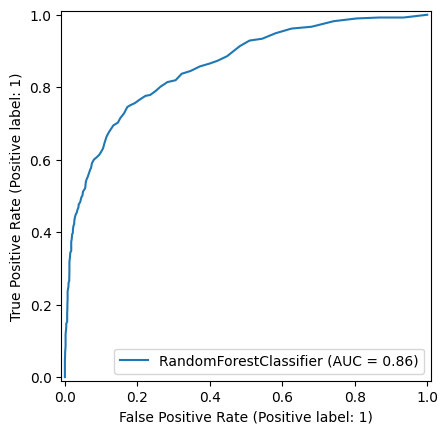

In [27]:
from sklearn.metrics import confusion_matrix, roc_auc_score, RocCurveDisplay

# Confusion Matrix
print(confusion_matrix(y_test, y_pred_rf))

# ROC-AUC
print("ROC-AUC:", roc_auc_score(y_test, y_pred_rf))

# ROC Curve
RocCurveDisplay.from_estimator(rf, X_test, y_test)
plt.show()

Feature Importance

This shows which features contribute most to predicting churn.

Insight:
- Helps identify key drivers of churn
- Useful for business decision-making

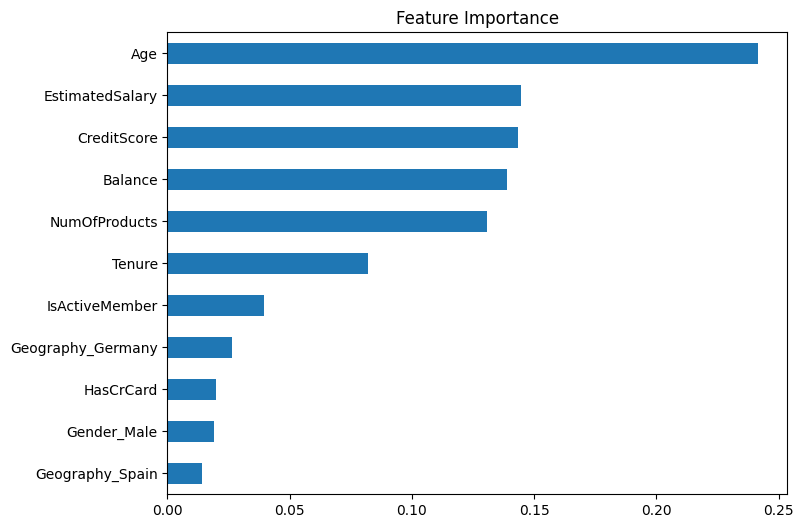

In [28]:
import pandas as pd

importance = rf.feature_importances_
features = pd.Series(importance, index=X.columns)

features.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance")
plt.show()